In [2]:
!pip install transformers datasets evaluate accelerate scikit-learn

In [3]:
import pandas as pd
from transformers import DataCollatorWithPadding,TrainingArguments,Trainer
import numpy as np
from sklearn.metrics import f1_score
import torchvision

In [4]:
df=pd.read_csv('Annotated_data.csv')
df.head()

,Id_Number,Patient Question,Distorted part,Dominant Distortion,Secondary Distortion (Optional)
0,4500,"Hello, I have a beautiful,smart,outgoing and a...",The voice are always fimilar (someone she know...,Personalization,NaN
1,4501,Since I was about 16 years old I’ve had these ...,I feel trapped inside my disgusting self and l...,Labeling,Emotional Reasoning
2,4502,So I’ve been dating on and off this guy for a...,NaN,No Distortion,NaN
3,4503,My parents got divorced in 2004. My mother has...,NaN,No Distortion,NaN
4,4504,I don’t really know how to explain the situati...,I refused to go because I didn’t know if it wa...,Fortune-telling,Emotional Reasoning


In [5]:
labels = sorted(df["Dominant Distortion"].unique())

In [6]:
labels

['All-or-nothing thinking',
 'Emotional Reasoning',
 'Fortune-telling',
 'Labeling',
 'Magnification',
 'Mental filter',
 'Mind Reading',
 'No Distortion',
 'Overgeneralization',
 'Personalization',
 'Should statements']

In [7]:
df1=pd.read_csv("data.csv")
df1.head()

,TEXT (BAHASA),TEXT (ENGLISH),DATA STATUS,FIRST ANNOTATOR,SECOND ANNOTATOR
0,ketika saya sudah berusaha semaksimal mungkin ...,when I have tried my best but am still not opt...,RAW-ORI,All-or-nothing,All-or-nothing
1,Saya ketika SD hingga SMP dulu beranggapan bah...,When I was in elementary school to middle scho...,RAW-ORI,All-or-nothing,All-or-nothing
2,Saya berfikir jika tidak lolos MBKM maka masa ...,I thought that if I didn't pass MBKM then my f...,RAW-ORI,All-or-nothing,All-or-nothing
3,"Di desa saya dulu ada dua kelompok pertemanan,...",In my village there were two friendship groups...,RAW-ORI,All-or-nothing,All-or-nothing
4,Saya hanya berteman dengan orang yang tidak me...,I only make friends with people who don't hurt...,RAW-ORI,All-or-nothing,All-or-nothing


In [8]:
label1=sorted(df1["FIRST ANNOTATOR"].unique())
label1

['All-or-nothing',
 'Discounting the positives',
 'Emotional Reasoning',
 'Fortune-telling',
 'Labeling',
 'Magnification or Minimization',
 'Mental filter',
 'Mind Reading',
 'No Distortion',
 'Overgeneralization',
 'Personalization and Blame',
 'Should statement']

In [13]:
replacements = {
    "All-or-nothing": "All-or-nothing thinking",
    "Magnification or Minimization": "Magnification",
    "Should statement": "Should statements",
    'Personalization and Blame':'Personalization'
}

cols = ["FIRST ANNOTATOR", "SECOND ANNOTATOR"]

for col in cols:
    df1[col] = df1[col].replace(replacements)

df1 = df1[
    ~(
        (df1["FIRST ANNOTATOR"] == "Discounting the positives") |
        (df1["SECOND ANNOTATOR"] == "Discounting the positives")
    )
]

In [43]:
label1=sorted(df1["FIRST ANNOTATOR"].unique())
set(labels)^set(label1)

set()

In [15]:
labels

['All-or-nothing thinking',
 'Emotional Reasoning',
 'Fortune-telling',
 'Labeling',
 'Magnification',
 'Mental filter',
 'Mind Reading',
 'No Distortion',
 'Overgeneralization',
 'Personalization',
 'Should statements']

In [45]:
df1=df1.rename(columns={'FIRST ANNOTATOR':'Dominant Distortion','SECOND ANNOTATOR':'Secondary Distortion (Optional)'})
df1.head()

,TEXT (BAHASA),TEXT (ENGLISH),DATA STATUS,Dominant Distortion,Secondary Distortion (Optional)
0,ketika saya sudah berusaha semaksimal mungkin ...,when I have tried my best but am still not opt...,RAW-ORI,All-or-nothing thinking,All-or-nothing thinking
1,Saya ketika SD hingga SMP dulu beranggapan bah...,When I was in elementary school to middle scho...,RAW-ORI,All-or-nothing thinking,All-or-nothing thinking
2,Saya berfikir jika tidak lolos MBKM maka masa ...,I thought that if I didn't pass MBKM then my f...,RAW-ORI,All-or-nothing thinking,All-or-nothing thinking
3,"Di desa saya dulu ada dua kelompok pertemanan,...",In my village there were two friendship groups...,RAW-ORI,All-or-nothing thinking,All-or-nothing thinking
4,Saya hanya berteman dengan orang yang tidak me...,I only make friends with people who don't hurt...,RAW-ORI,All-or-nothing thinking,All-or-nothing thinking


In [16]:
len(df),len(df1)

(2530, 4751)

In [17]:
dist2id = {
    d:i
    for i,d in enumerate(labels)
}

In [18]:
def encode_labels(row):
    num = [0] * len(labels)

    num[dist2id[row["Dominant Distortion"]]] = 1

    if pd.notna(row["Secondary Distortion (Optional)"]):
        num[dist2id[row["Secondary Distortion (Optional)"]]] = 1

    return num

In [46]:
# df["labels"] = df.apply(
#     encode_labels,
#     axis=1
# )
df1["labels"] = df1.apply(
    encode_labels,
    axis=1
)

In [47]:
# final_df = df[["Distorted part", "labels"]]
# final_df.head()

df1_subset = (
    df1.rename(
        columns={"TEXT (ENGLISH)": "Distorted part"}
    )[["Distorted part", "labels"]]
)

final_df = pd.concat(
    [final_df, df1_subset],
    ignore_index=True
)
len(final_df)

7281

In [21]:
final_df["Distorted part"] = final_df["Distorted part"].fillna(df["Patient Question"])
final_df["labels"] = final_df["labels"].apply(
    lambda lst: [float(x) for x in lst]
)
final_df.head()

/tmp/ipykernel_1070/3047749128.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["Distorted part"] = final_df["Distorted part"].fillna(df["Patient Question"])
/tmp/ipykernel_1070/3047749128.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["labels"] = final_df["labels"].apply(


,Distorted part,labels
0,The voice are always fimilar (someone she know...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,I feel trapped inside my disgusting self and l...,"[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,So I’ve been dating on and off this guy for a...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
3,My parents got divorced in 2004. My mother has...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4,I refused to go because I didn’t know if it wa...,"[0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [48]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    final_df,
    test_size=0.2,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

In [49]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)
test_ds = Dataset.from_pandas(test_df)

In [73]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

MODEL_NAME = "/content/modernbert_cbt/checkpoint-635"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

In [25]:
def tokenize(batch):
    return tokenizer(
        batch["Distorted part"],
        truncation=True,
        max_length=256
    )

In [51]:
train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/5824 [00:00<?, ? examples/s]

Map:   0%|          | 0/728 [00:00<?, ? examples/s]

Map:   0%|          | 0/729 [00:00<?, ? examples/s]

In [52]:
lengths = [len(tokenizer.encode(x)) for x in final_df["Distorted part"]]
print(max(lengths))
print(sum(lengths)/len(lengths))

618
54.61584947122648


In [53]:
import numpy as np

lengths = [len(tokenizer.encode(x)) for x in final_df["Distorted part"]]

print("50th percentile:", np.percentile(lengths, 50))
print("90th percentile:", np.percentile(lengths, 90))
print("95th percentile:", np.percentile(lengths, 95))
print("99th percentile:", np.percentile(lengths, 99))
print("Max:", max(lengths))

50th percentile: 36.0
90th percentile: 110.0
95th percentile: 156.0
99th percentile: 325.9999999999991
Max: 618


In [29]:
data_collator = DataCollatorWithPadding(tokenizer)

In [54]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))

    preds = (probs > 0.5).astype(int)

    macro_f1 = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    micro_f1 = f1_score(
        labels,
        preds,
        average="micro",
        zero_division=0
    )

    return {
        "macro_f1": macro_f1,
        "micro_f1": micro_f1
    }

In [74]:
training_args = TrainingArguments(
    output_dir="./modernbert_cbt",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="macro_f1"
)

In [75]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    load_best_model_at_end=True
)

In [81]:
trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1,Micro F1
1,No log,0.149618,0.563054,0.664710
2,0.141052,0.146207,0.615636,0.710035
3,0.057232,0.151397,0.611015,0.708752
4,0.057232,0.161499,0.624103,0.714906
5,0.014523,0.170420,0.607168,0.711913


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1820, training_loss=0.059155838437132784, metrics={'train_runtime': 1539.6891, 'train_samples_per_second': 18.913, 'train_steps_per_second': 1.182, 'total_flos': 3391944844789248.0, 'train_loss': 0.059155838437132784, 'epoch': 5.0})

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [37]:
test_results = trainer.evaluate(test_ds)

print(test_results)

Training Loss,Validation Loss,Epoch,Macro F1,Micro F1
0.174441,0.230022,5,0.399162,0.583673


{'eval_loss': 0.23002150654792786, 'eval_macro_f1': 0.39916209855328816, 'eval_micro_f1': 0.5836734693877551}


In [39]:
predictions = trainer.predict(test_ds)
logits = predictions.predictions

# Convert logits to probabilities and then to binary predictions
probs = 1 / (1 + np.exp(-logits))
y_pred = (probs > 0.5).astype(int)
y_true = np.array(test_ds['labels'])

label_names = labels


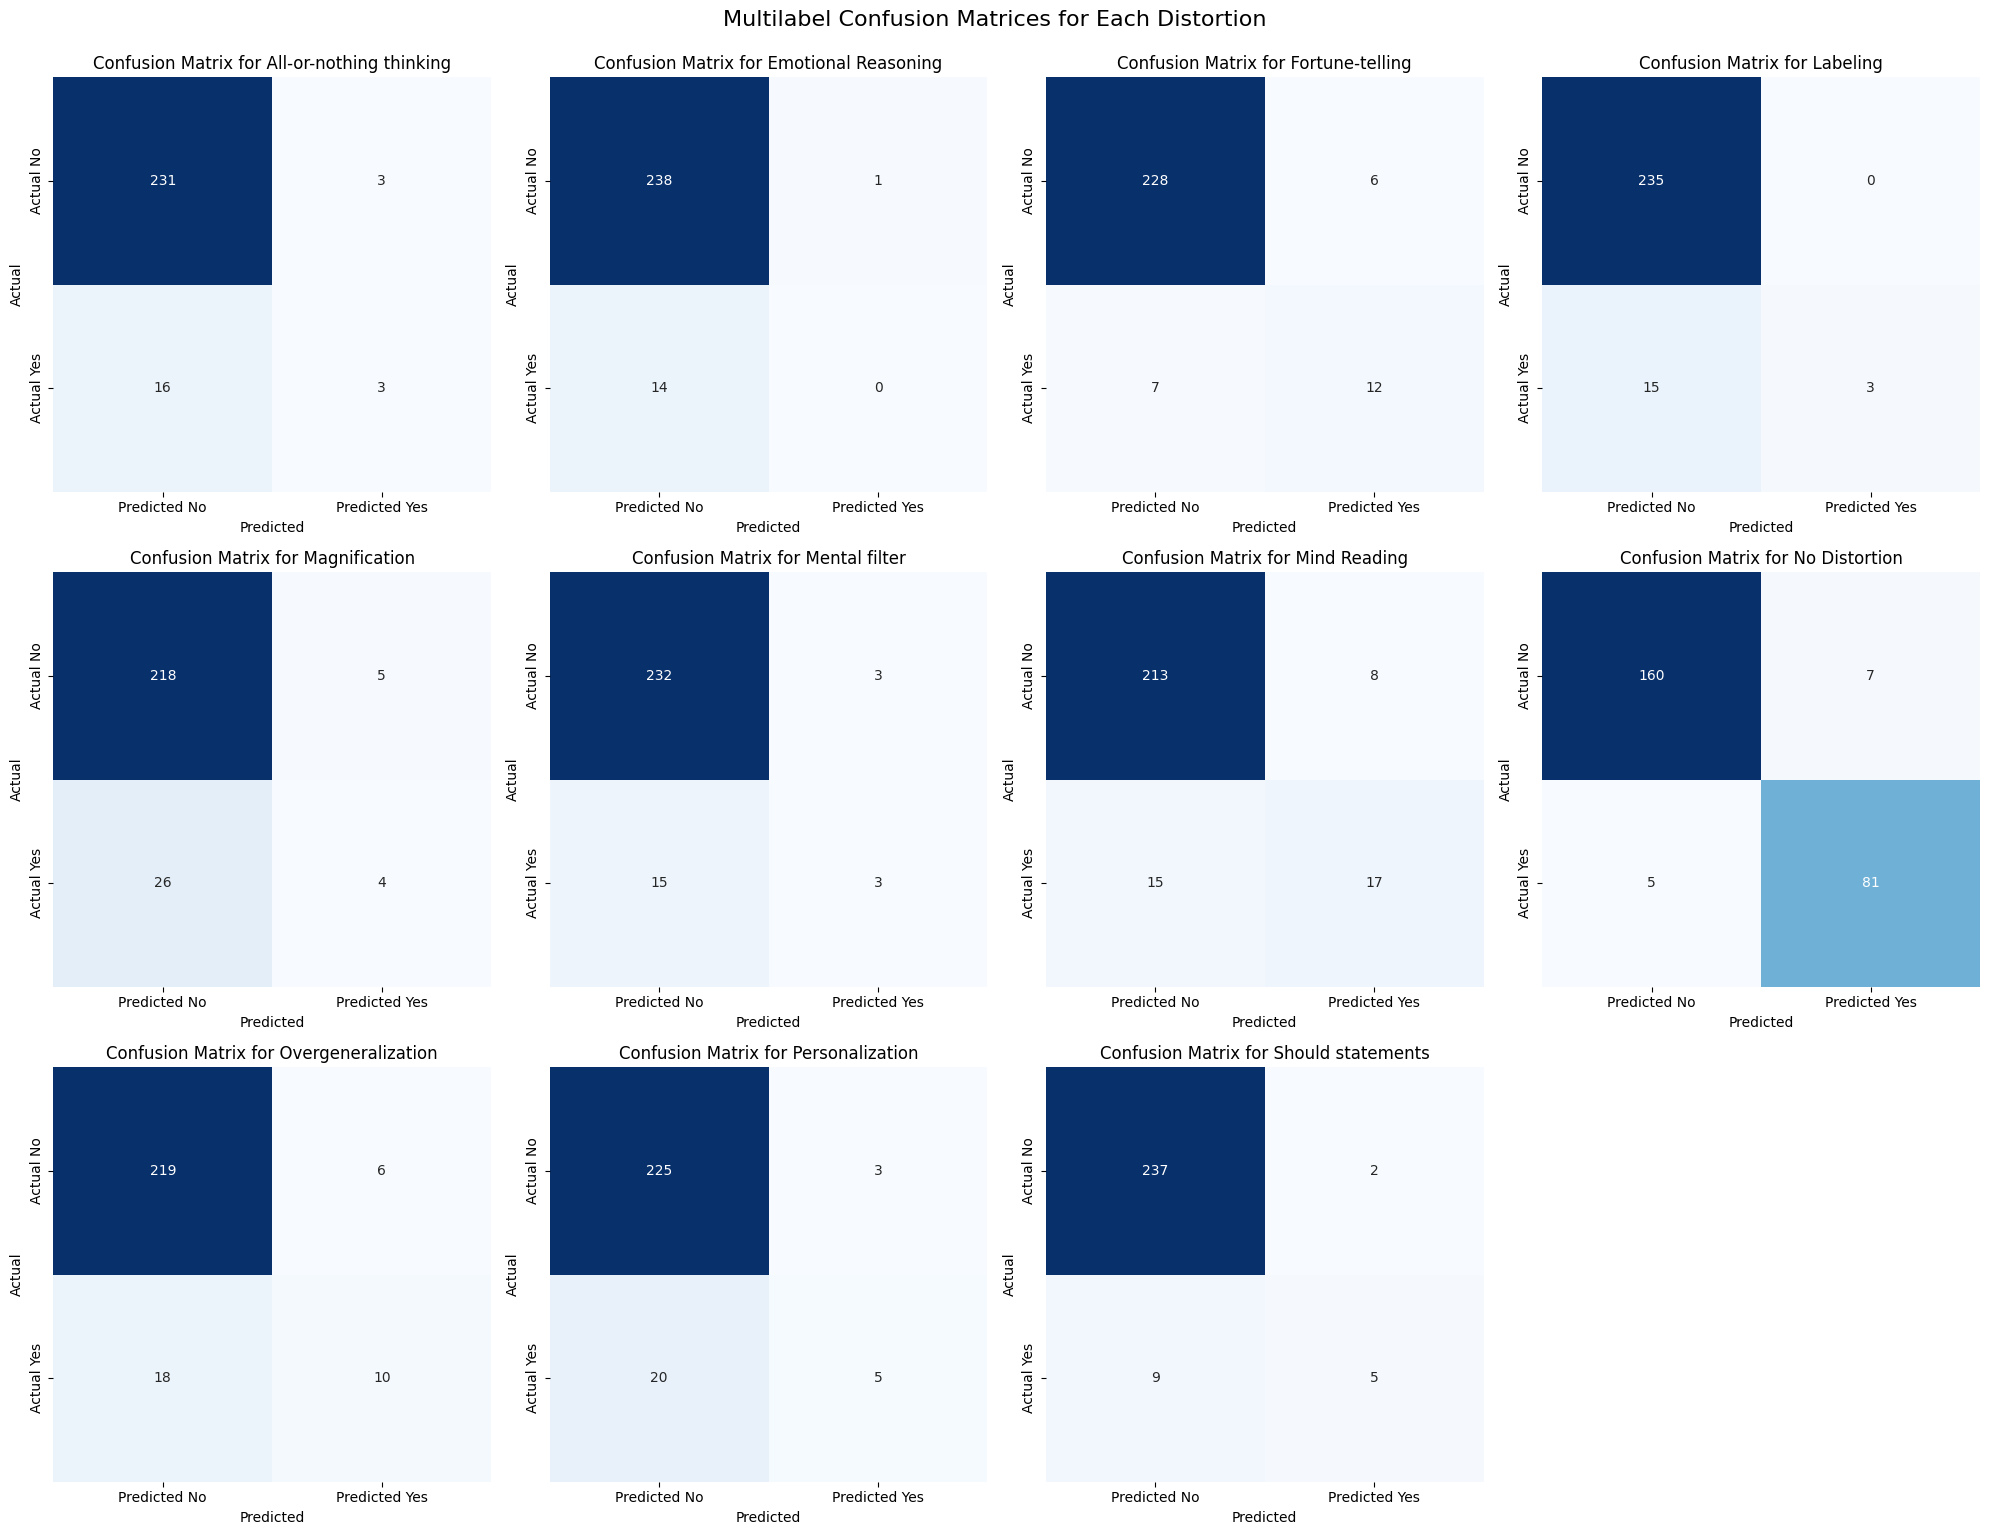

In [40]:
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute multilabel confusion matrix
mlcm = multilabel_confusion_matrix(y_true, y_pred)

# Visualize each confusion matrix
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, (matrix, label_name) in enumerate(zip(mlcm, label_names)):
    ax = axes[i]
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Actual No', 'Actual Yes'], ax=ax)
    ax.set_title(f'Confusion Matrix for {label_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Multilabel Confusion Matrices for Each Distortion', y=1.02, fontsize=16)
plt.show()


In [41]:
# The classification report was already set up in cell S1hAknf0P71T, I will just re-execute it after y_true and y_pred are defined
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        zero_division=0
    )
)


                         precision    recall  f1-score   support

All-or-nothing thinking       0.50      0.16      0.24        19
    Emotional Reasoning       0.00      0.00      0.00        14
        Fortune-telling       0.67      0.63      0.65        19
               Labeling       1.00      0.17      0.29        18
          Magnification       0.44      0.13      0.21        30
          Mental filter       0.50      0.17      0.25        18
           Mind Reading       0.68      0.53      0.60        32
          No Distortion       0.92      0.94      0.93        86
     Overgeneralization       0.62      0.36      0.45        28
        Personalization       0.62      0.20      0.30        25
      Should statements       0.71      0.36      0.48        14

              micro avg       0.76      0.47      0.58       303
              macro avg       0.61      0.33      0.40       303
           weighted avg       0.68      0.47      0.52       303
            samples avg

In [42]:
final_df.head(

)

,Distorted part,labels
0,The voice are always fimilar (someone she know...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,I feel trapped inside my disgusting self and l...,"[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,So I’ve been dating on and off this guy for a...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
3,My parents got divorced in 2004. My mother has...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4,I refused to go because I didn’t know if it wa...,"[0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [68]:
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 3            |        cudaMalloc retries: 4         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   6892 MiB |   6904 MiB |   2676 GiB |   2669 GiB |
|       from large pool |   6883 MiB |   6895 MiB |   2673 GiB |   2666 GiB |
|       from small pool |      8 MiB |     27 MiB |      3 GiB |      3 GiB |
|---------------------------------------------------------------------------|
| Active memory         |   6892 MiB |   6904 MiB |   2676 GiB |   2669 GiB |
|       from large pool |   6883 MiB |   6895 MiB |   2673 GiB |

In [78]:
import os
print(os.getpid())

1070


In [71]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

!nvidia-smi

Thu Jun 11 15:51:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             36W /   70W |    9815MiB /  15360MiB |     93%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [79]:
!kill -9 1073

In [80]:
!nvidia-smi

Thu Jun 11 15:57:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             33W /   70W |    7739MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [82]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "/content/modernbert_cbt/checkpoint-728"
)

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

In [91]:
best_trainer = Trainer(
    model=model,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    eval_dataset=val_ds
)

In [92]:
best_trainer.evaluate(test_ds)

Training Loss,Validation Loss,Step,Macro F1,Micro F1
No log,0.143334,0,0.584288,0.701408


{'eval_loss': 0.1433337926864624,
 'eval_macro_f1': 0.5842881715040347,
 'eval_micro_f1': 0.7014084507042253}

In [93]:
predictions = best_trainer.predict(test_ds)
logits = predictions.predictions

# Convert logits to probabilities and then to binary predictions
probs = 1 / (1 + np.exp(-logits))
y_pred = (probs > 0.5).astype(int)
y_true = np.array(test_ds['labels'])

label_names = labels


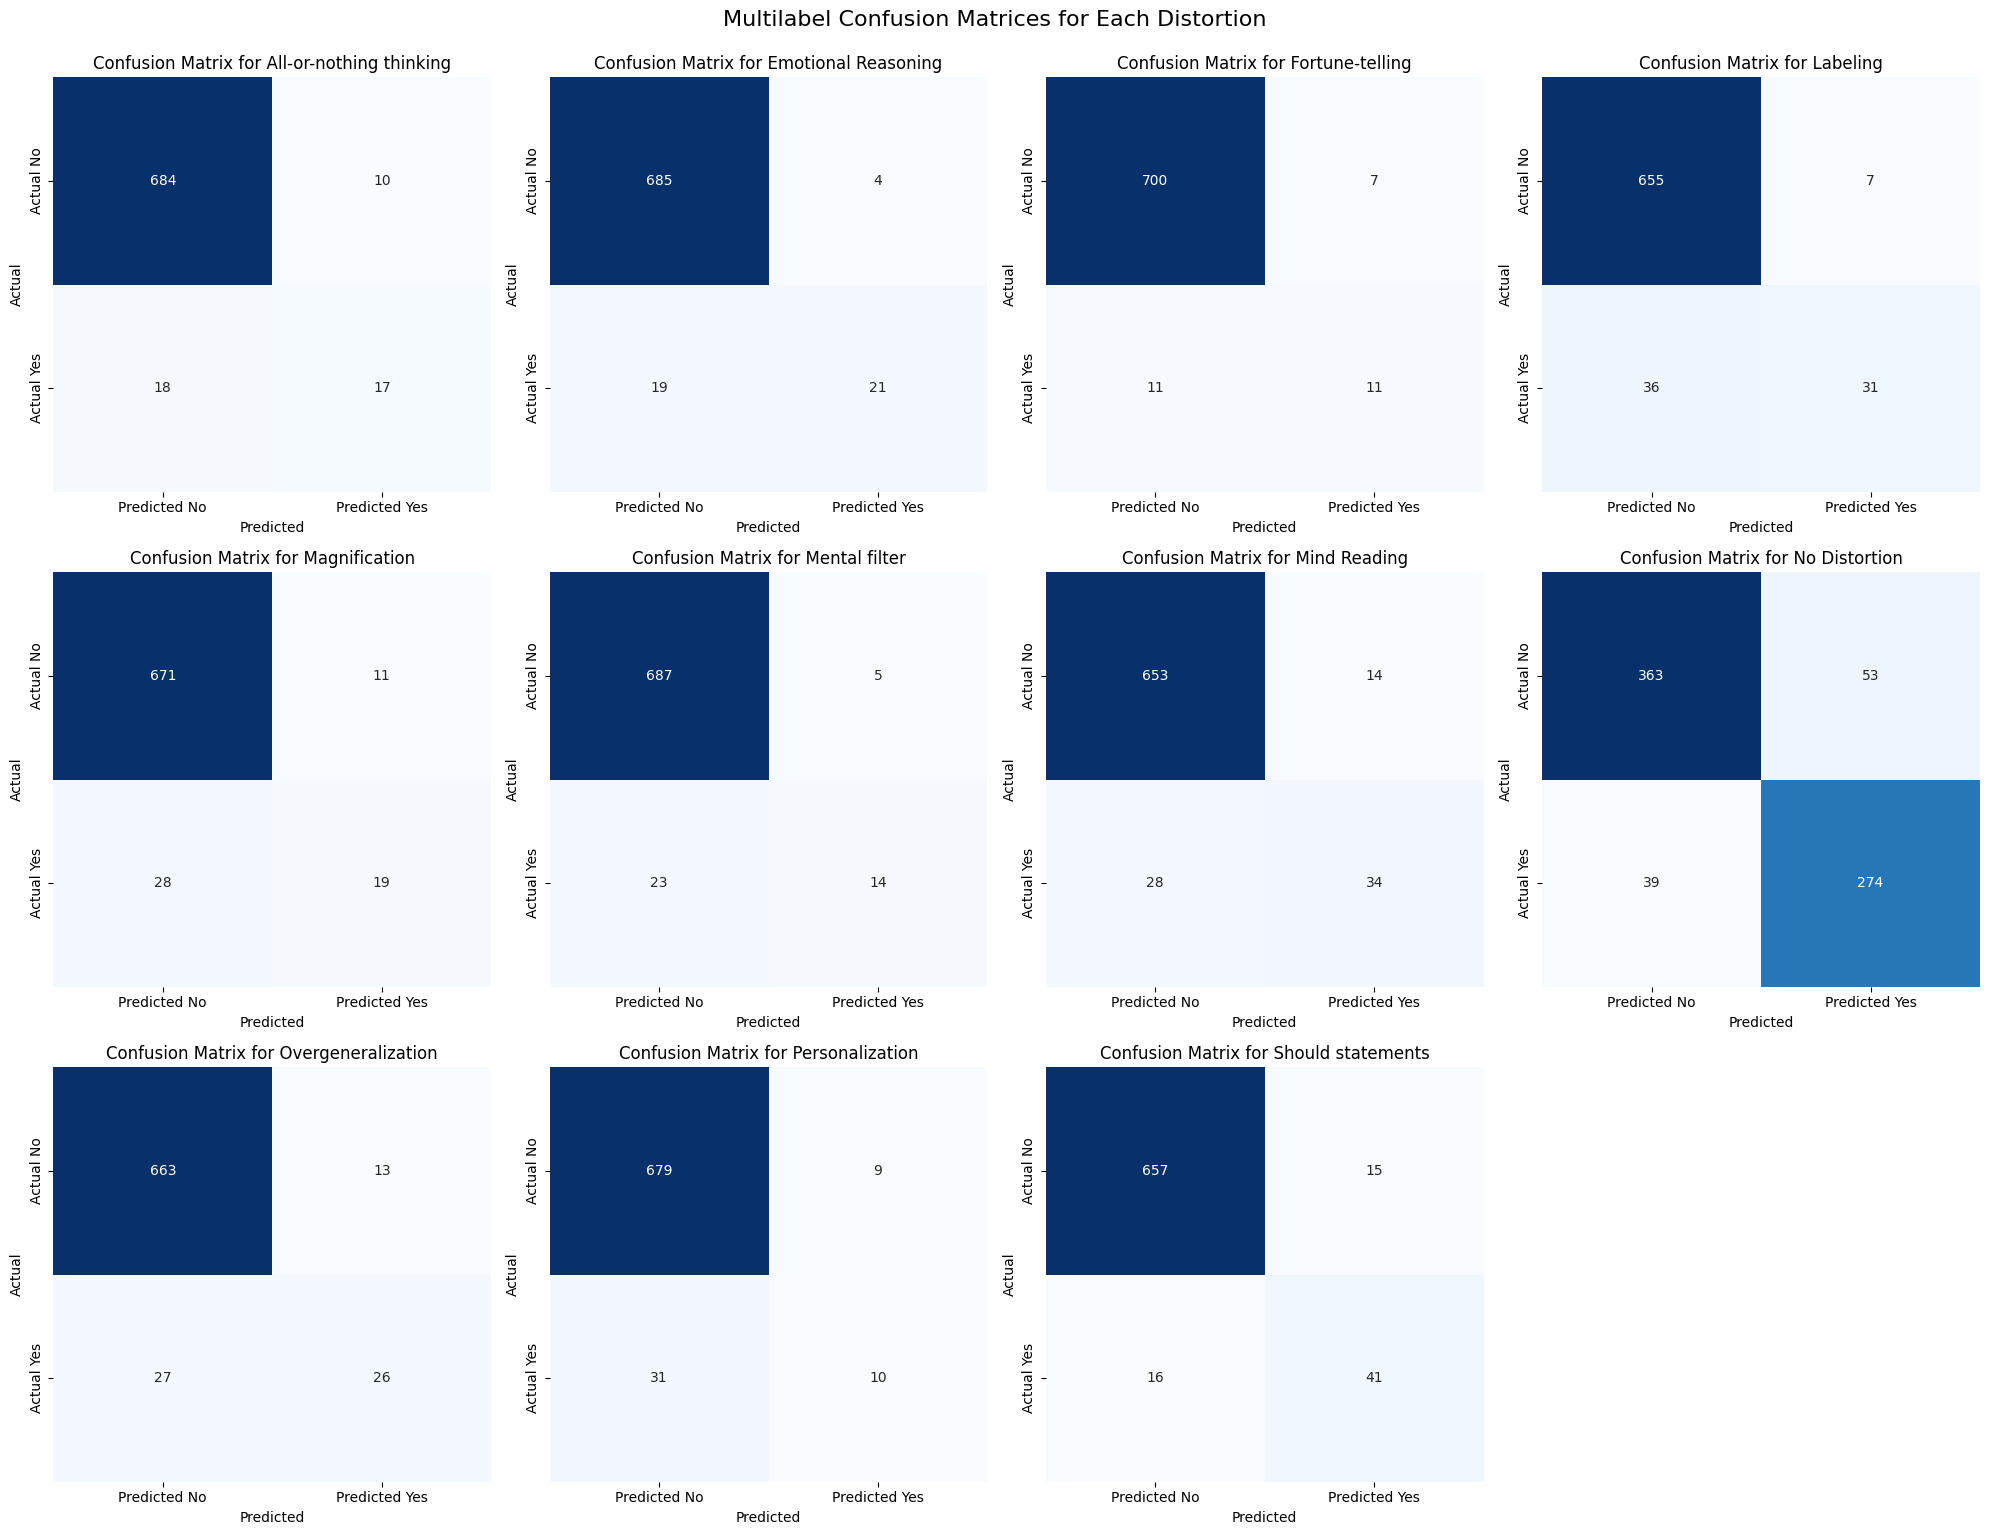

In [94]:
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute multilabel confusion matrix
mlcm = multilabel_confusion_matrix(y_true, y_pred)

# Visualize each confusion matrix
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
axes = axes.flatten()

for i, (matrix, label_name) in enumerate(zip(mlcm, label_names)):
    ax = axes[i]
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Actual No', 'Actual Yes'], ax=ax)
    ax.set_title(f'Confusion Matrix for {label_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Multilabel Confusion Matrices for Each Distortion', y=1.02, fontsize=16)
plt.show()

In [95]:
# The classification report was already set up in cell S1hAknf0P71T, I will just re-execute it after y_true and y_pred are defined
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_names,
        zero_division=0
    )
)


                         precision    recall  f1-score   support

All-or-nothing thinking       0.63      0.49      0.55        35
    Emotional Reasoning       0.84      0.53      0.65        40
        Fortune-telling       0.61      0.50      0.55        22
               Labeling       0.82      0.46      0.59        67
          Magnification       0.63      0.40      0.49        47
          Mental filter       0.74      0.38      0.50        37
           Mind Reading       0.71      0.55      0.62        62
          No Distortion       0.84      0.88      0.86       313
     Overgeneralization       0.67      0.49      0.57        53
        Personalization       0.53      0.24      0.33        41
      Should statements       0.73      0.72      0.73        57

              micro avg       0.77      0.64      0.70       774
              macro avg       0.70      0.51      0.58       774
           weighted avg       0.76      0.64      0.68       774
            samples avg

In [97]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_path = "/content/modernbert_cbt/checkpoint-728"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.eval()

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

ModernBertForSequenceClassification(
  (model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=False)
        )
      )
      (1-21): 21 x ModernBertEncoderLayer(
       

In [98]:
id2label = {
    0: "All-or-nothing thinking",
    1: "Emotional Reasoning",
    2: "Fortune-Telling",
    3: "Labeling",
    4: "Magnification",
    5: "Mental filter",
    6: "Mind Reading",
    7: "No Distortion",
    8: "Overgeneralization",
    9: "Personalization",
    10: "Should statements"
}

In [108]:
text = "I am losing my grip in life.Nothing feels real anymore.I am not sure if I exist, or if I want to exist.What is the point to life."
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    max_length=256
)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

probs = torch.sigmoid(logits)[0]

In [109]:
results = [
    (id2label[i], probs[i].item())
    for i in range(len(probs))
]

results = sorted(
    results,
    key=lambda x: x[1],
    reverse=True
)

for distortion, prob in results:
    print(f"{distortion}: {prob:.4f}")

All-or-nothing thinking: 0.5661
Overgeneralization: 0.2136
Magnification: 0.0649
Fortune-Telling: 0.0380
Mental filter: 0.0368
Emotional Reasoning: 0.0238
No Distortion: 0.0188
Personalization: 0.0084
Should statements: 0.0031
Mind Reading: 0.0014
Labeling: 0.0010
